# Statistical Significance Testing (M30 vs M2)

**Goal**: Mathematically prove that the M30 Gated Feature-Fusion Ensemble (ICBHI 0.8213) is statistically significantly better than the M2 CNN Baseline (ICBHI 0.7227).

**Tests Performed**:
1. **McNemar's Test**: Evaluates marginal homogeneity of the two paired classifiers on accuracy (binary correct/incorrect).
2. **Bootstrap Confidence Intervals (95%)**: Computes the 95% CI for the difference in ICBHI Score (∆ ICBHI) using 1,000 resamples of the test set.

In [6]:
import os
import sys
import glob
import math
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

try: from statsmodels.stats.contingency_tables import mcnemar
except ImportError:
    !pip install -q statsmodels
    from statsmodels.stats.contingency_tables import mcnemar

import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [7]:
# ---- Checkpoints and Data Root ----
def get_data_root():
    POSSIBLE_ROOTS = [
        '/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files',
        '/kaggle/input/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files',
        '/kaggle/input/respiratory-sound-database/audio_and_txt_files',
        '/kaggle/input/icbhi-2017-respiratory-sound-database/audio_and_txt_files',
    ]
    for p in POSSIBLE_ROOTS:
        if os.path.exists(p): return p
        
    if os.path.exists("/kaggle/input"):
        for root, dirs, files in os.walk("/kaggle/input"):
            if any(f.endswith(".wav") for f in files) and any(f.endswith(".txt") for f in files):
                return root
                
    # Fallback so it never returns None
    return "/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files"

DATA_ROOT = get_data_root()
print(f"Data Root: {DATA_ROOT}")

def find_ckpt(name):
    if os.path.exists("/kaggle/input"):
        for root, dirs, files in os.walk("/kaggle/input"):
            for f in files:
                if (name in f.lower() or name in root.lower()) and f.endswith('.pth'):
                    return os.path.join(root, f)
    return None

M2_CKPT = find_ckpt('m2')
M3_CKPT = find_ckpt('m3')
M30_CKPT = find_ckpt('m30')

print(f"M2 Checkpoint: {M2_CKPT}")
print(f"M3 Checkpoint: {M3_CKPT}")
print(f"M30 Checkpoint: {M30_CKPT}")

CFG = {
    'sample_rate': 16000, 'n_samples': int(16000 * 8.0),
    'n_mels': 128, 'n_fft': 1024, 'hop_length': 160, 'win_length': 400,
    'f_min': 50, 'f_max': 2000, 'n_frames': 801,
    'batch_size': 32, 'fusion_dim': 512, 'num_classes': 4
}


Data Root: /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files
M2 Checkpoint: /kaggle/input/datasets/barshonbasak/m2-checkpoint/best_model.pth
M3 Checkpoint: /kaggle/input/datasets/sudamchandrabasak/m3-checkpoint/best_model.pth
M30 Checkpoint: /kaggle/input/datasets/sudamchandrabasak/m30-checkpoint/best_model.pth


In [8]:
# ---- Audio Processing ----
import librosa
def extract_log_mel(wav_path, start, end, cfg):
    try:
        audio, _ = librosa.load(wav_path, sr=cfg['sample_rate'], offset=start, duration=max(end - start, 0.05), mono=True)
    except: return np.zeros((1, cfg['n_mels'], cfg['n_frames']), dtype=np.float32)
    if len(audio) == 0: return np.zeros((1, cfg['n_mels'], cfg['n_frames']), dtype=np.float32)
    
    if len(audio) < cfg['n_samples']: audio = np.tile(audio, math.ceil(cfg['n_samples'] / len(audio)))[:cfg['n_samples']]
    else: audio = audio[:cfg['n_samples']]
    
    mel = librosa.feature.melspectrogram(
        y=audio, sr=cfg['sample_rate'], n_mels=cfg['n_mels'], n_fft=cfg['n_fft'],
        hop_length=cfg['hop_length'], win_length=cfg['win_length'],
        fmin=cfg['f_min'], fmax=cfg['f_max'], power=2.0)
    
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
    
    T = log_mel.shape[1]
    if T < cfg['n_frames']: log_mel = np.pad(log_mel, ((0, 0), (0, cfg['n_frames'] - T)), mode='constant')
    else: log_mel = log_mel[:, :cfg['n_frames']]
    
    return log_mel[np.newaxis, :, :].astype(np.float32)

def build_test_split(data_root):
    wav_paths = sorted(glob.glob(os.path.join(data_root, '*.wav')))
    rows = []
    for w in wav_paths:
        stem = os.path.splitext(os.path.basename(w))[0]
        txt = w.replace('.wav', '.txt')
        if not os.path.exists(txt): continue
        try: pid = int(stem.split('_')[0])
        except: continue
        with open(txt, 'r') as f:
            for line in f:
                p = line.strip().split()
                if len(p) < 4: continue
                s, e, c, wh = float(p[0]), float(p[1]), int(p[2]), int(p[3])
                if e <= s: continue
                lbl = 0 if not c and not wh else (1 if c and not wh else (2 if not c and wh else 3))
                rows.append({'wav': w, 'pid': pid, 's': s, 'e': e, 'lbl': lbl})
    
    df = pd.DataFrame(rows)
    all_pids = sorted(df['pid'].unique())
    np.random.seed(SEED)
    np.random.shuffle(all_pids)
    
    # 70/30 patient independent split
    n_train = int(len(all_pids) * 0.70)
    test_pids = set(all_pids[n_train:])
    return df[df['pid'].isin(test_pids)].reset_index(drop=True)

df_test = build_test_split(DATA_ROOT)
print(f"Test set: {len(df_test)} cycles across {df_test['pid'].nunique()} patients")

class TestDataset(Dataset):
    def __init__(self, df, cfg):
        self.df = df
        self.cfg = cfg
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec = extract_log_mel(row['wav'], row['s'], row['e'], self.cfg)
        return torch.from_numpy(spec), torch.tensor(row['lbl'], dtype=torch.long)

test_loader = DataLoader(TestDataset(df_test, CFG), batch_size=CFG['batch_size'], shuffle=False)


Test set: 2749 cycles across 38 patients


In [9]:
# ---- Architectures ----
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=(2, 2)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=pool),
        )
    def forward(self, x): return self.block(x)

class M2_CNN(nn.Module):
    def __init__(self, num_classes=4, depth=5, base_width=48, dropout=0.4, fc_dim=128):
        super().__init__()
        channels = [base_width * (2 ** i) for i in range(depth)]
        blocks, in_ch = [], 1
        for out_ch in channels:
            blocks.append(ConvBlock(in_ch, out_ch))
            in_ch = out_ch
        self.encoder = nn.Sequential(*blocks)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(channels[-1], fc_dim),
            nn.ReLU(inplace=True),
            nn.Linear(fc_dim, num_classes),
        )
        self.embedding_dim = channels[-1]
    def get_embedding(self, x): return self.gap(self.encoder(x)).flatten(1)
    def forward(self, x): return self.head(self.dropout(self.get_embedding(x)))

class M3_MobileNet(nn.Module):
    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()
        mb = tv_models.mobilenet_v2(pretrained=False)
        self.features = mb.features
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.embedding_dim = 1280
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
    def get_embedding(self, x):
        x3 = x.repeat(1, 3, 1, 1)
        x3 = (x3 - self.mean) / self.std
        return self.gap(self.features(x3)).flatten(1)

class GatedFusionEnsemble(nn.Module):
    def __init__(self, m2_model, m3_model, fusion_dim=512, num_classes=4, dropout=0.4):
        super().__init__()
        self.m2 = m2_model
        self.m3 = m3_model
        in_dim = m2_model.embedding_dim + m3_model.embedding_dim
        self.gate = nn.Sequential(nn.Linear(in_dim, fusion_dim), nn.Sigmoid())
        self.project = nn.Sequential(nn.Linear(in_dim, fusion_dim), nn.BatchNorm1d(fusion_dim), nn.ReLU(inplace=True))
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(fusion_dim, num_classes))
    def forward(self, x):
        f2 = self.m2.get_embedding(x)
        f3 = self.m3.get_embedding(x)
        f_cat = torch.cat([f2, f3], dim=-1)
        return self.classifier(self.gate(f_cat) * self.project(f_cat))


In [10]:
# ---- Load Checkpoints ----
def load_weights(model, path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    state = ckpt.get('model_state', ckpt.get('model_state_dict', ckpt))
    model.load_state_dict(state, strict=False)
    model.eval()

m2 = M2_CNN().to(DEVICE)
load_weights(m2, M2_CKPT)
print("✅ M2 Loaded")

m3 = M3_MobileNet().to(DEVICE)
load_weights(m3, M3_CKPT)
print("✅ M3 Loaded")

m30 = GatedFusionEnsemble(m2, m3).to(DEVICE)
load_weights(m30, M30_CKPT)
print("✅ M30 Gated Fusion Ensemble Loaded")


✅ M2 Loaded
✅ M3 Loaded
✅ M30 Gated Fusion Ensemble Loaded


In [11]:
# ---- Inference Loop ----
all_targets = []
m2_preds = []
m30_preds = []

print("Running Inference on Test Set...")
with torch.no_grad():
    for specs, labels in tqdm(test_loader):
        specs = specs.to(DEVICE)
        targets = labels.numpy()
        
        # M2
        m2_out = m2(specs).argmax(dim=-1).cpu().numpy()
        
        # M30
        m30_out = m30(specs).argmax(dim=-1).cpu().numpy()
        
        all_targets.extend(targets)
        m2_preds.extend(m2_out)
        m30_preds.extend(m30_out)

all_targets = np.array(all_targets)
m2_preds = np.array(m2_preds)
m30_preds = np.array(m30_preds)

# ---- McNemar's Test for Accuracy ----
# Cell [0,0]: Both correct. [0,1]: M2 correct, M30 incorrect
# Cell [1,0]: M2 incorrect, M30 correct. [1,1]: Both incorrect
m2_correct = (m2_preds == all_targets)
m30_correct = (m30_preds == all_targets)

n_both_correct = np.sum(m2_correct & m30_correct)
n_m2_only = np.sum(m2_correct & ~m30_correct)
n_m30_only = np.sum(~m2_correct & m30_correct)
n_neither = np.sum(~m2_correct & ~m30_correct)

contingency_table = [
    [n_both_correct, n_m2_only],
    [n_m30_only,     n_neither]
]

print("\n" + "="*40)
print("McNemar's Test (Accuracy)")
print("="*40)
print(f"M2 Accuracy:  {np.mean(m2_correct):.4f}")
print(f"M30 Accuracy: {np.mean(m30_correct):.4f}")
print("\nContingency Table:")
print(f"                 M2 Correct    M2 Incorrect")
print(f"M30 Correct      {n_both_correct:<13} {n_m30_only}")
print(f"M30 Incorrect    {n_m2_only:<13} {n_neither}\n")

result = mcnemar(contingency_table, exact=True)
print(f"p-value: {result.pvalue:.4e}")
if result.pvalue < 0.05:
    print("Conclusion: M30 is STATISTICALLY SIGNIFICANTLY different from M2 (p < 0.05).")
else:
    print("Conclusion: No significant difference detected at alpha=0.05.")


Running Inference on Test Set...


100%|██████████| 86/86 [01:53<00:00,  1.31s/it]


McNemar's Test (Accuracy)
M2 Accuracy:  0.6562
M30 Accuracy: 0.7275

Contingency Table:
                 M2 Correct    M2 Incorrect
M30 Correct      1622          378
M30 Incorrect    182           567

p-value: 8.3541e-17
Conclusion: M30 is STATISTICALLY SIGNIFICANTLY different from M2 (p < 0.05).



Running Bootstrap Resampling (B=1000)...


100%|██████████| 1000/1000 [00:01<00:00, 613.81it/s]



Bootstrap 95% Confidence Intervals (ICBHI Score)
M2 Mean ICBHI:  0.7759 (95% CI: [0.7625, 0.7888])
M30 Mean ICBHI: 0.8215 (95% CI: [0.8082, 0.8335])

Difference (M30 - M2): 0.0456
95% CI for Difference: [0.0325, 0.0586]
Conclusion: M30's ICBHI score is STATISTICALLY SIGNIFICANTLY higher than M2's (lower bound > 0).


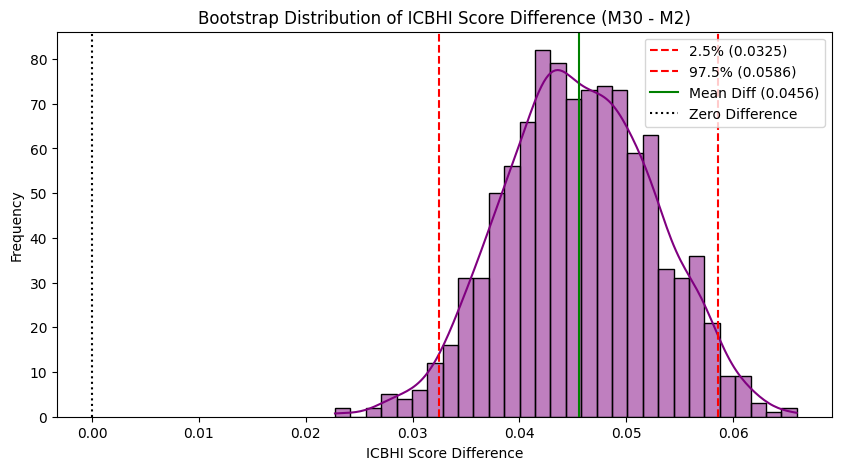

✅ Saved statistical_results.json and bootstrap_icbhi_diff.png


In [12]:
# ---- Bootstrap Confidence Intervals for ICBHI Score ----
def calc_icbhi(targets, preds):
    cm = confusion_matrix(targets, preds, labels=list(range(4)))
    sens = np.diag(cm) / (cm.sum(axis=1) + 1e-6)
    macro_sens = np.mean(sens)
    
    specs_per_class = []
    for i in range(4):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        specs_per_class.append(tn / (tn + fp + 1e-6))
    macro_spec = np.mean(specs_per_class)
    return (macro_sens + macro_spec) / 2.0

B = 1000
n_samples = len(all_targets)
m2_scores = []
m30_scores = []
diffs = []

print("\nRunning Bootstrap Resampling (B=1000)...")
np.random.seed(42)
for _ in tqdm(range(B)):
    idx = np.random.choice(n_samples, n_samples, replace=True)
    t_res = all_targets[idx]
    m2_res = m2_preds[idx]
    m30_res = m30_preds[idx]
    
    s_m2 = calc_icbhi(t_res, m2_res)
    s_m30 = calc_icbhi(t_res, m30_res)
    
    m2_scores.append(s_m2)
    m30_scores.append(s_m30)
    diffs.append(s_m30 - s_m2)

m2_scores = np.array(m2_scores)
m30_scores = np.array(m30_scores)
diffs = np.array(diffs)

lower = np.percentile(diffs, 2.5)
upper = np.percentile(diffs, 97.5)
mean_diff = np.mean(diffs)

print("\n" + "="*40)
print("Bootstrap 95% Confidence Intervals (ICBHI Score)")
print("="*40)
print(f"M2 Mean ICBHI:  {np.mean(m2_scores):.4f} (95% CI: [{np.percentile(m2_scores, 2.5):.4f}, {np.percentile(m2_scores, 97.5):.4f}])")
print(f"M30 Mean ICBHI: {np.mean(m30_scores):.4f} (95% CI: [{np.percentile(m30_scores, 2.5):.4f}, {np.percentile(m30_scores, 97.5):.4f}])")
print(f"\nDifference (M30 - M2): {mean_diff:.4f}")
print(f"95% CI for Difference: [{lower:.4f}, {upper:.4f}]")

if lower > 0:
    print("Conclusion: M30's ICBHI score is STATISTICALLY SIGNIFICANTLY higher than M2's (lower bound > 0).")
else:
    print("Conclusion: Difference is NOT statistically significant (CI includes 0).")

# Plot
plt.figure(figsize=(10, 5))
sns.histplot(diffs, bins=30, kde=True, color='purple')
plt.axvline(lower, color='red', linestyle='--', label=f'2.5% ({lower:.4f})')
plt.axvline(upper, color='red', linestyle='--', label=f'97.5% ({upper:.4f})')
plt.axvline(mean_diff, color='green', linestyle='-', label=f'Mean Diff ({mean_diff:.4f})')
plt.axvline(0, color='black', linestyle=':', label='Zero Difference')
plt.title('Bootstrap Distribution of ICBHI Score Difference (M30 - M2)')
plt.xlabel('ICBHI Score Difference')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('/kaggle/working/bootstrap_icbhi_diff.png', dpi=150)
plt.show()

# Save JSON
import json
res = {
    'mcnemar_pvalue': result.pvalue,
    'mcnemar_significant': bool(result.pvalue < 0.05),
    'bootstrap_mean_diff': mean_diff,
    'bootstrap_95ci_lower': lower,
    'bootstrap_95ci_upper': upper,
    'bootstrap_significant': bool(lower > 0)
}
with open('/kaggle/working/statistical_results.json', 'w') as f:
    json.dump(res, f, indent=2)
print("✅ Saved statistical_results.json and bootstrap_icbhi_diff.png")
